# **🍺Análise Preditiva de Demanda: Consumo de Cerveja em São Paulo**

## **Previsão de Consumo para Previsão de Estoque e Planejamento Logístico**

1. **Problema de Negócio**: Previsão da demanda de consumo de cerveja para otimizar a gestão de estoque e a logística de distribuição. Utilizar modelos estatísticos permite que a empresa evite a falta de estoque em dias de alta demanda e reduza custos com excesso de mercadoria parada.

2. **Base de Dados:**  Fonte: Kaggle - Beer Consumption São Paulo  
https://www.kaggle.com/datasets/dongeorge/beer-consumption-sao-paulo  
Os dados foram coletados em São Paulo no ano de 2015 (região universitária), contendo registros diários (365 dias) de consumo (litros) versus temperatura e pluviosidade.  
Variáveis analisadas: Temperatura Máxima (°C), Precipitação (mm), Final de Semana e Consumo (Litros).

3. **Objetivo:** Prever o consumo de cerveja (em litros) com base na variáveis independentes.
com o uso de modelos de regressão linear simples e múltipla, visando garantir que a oferta acompanhe a demanda climática e período da semana.

4. **Metodologia:** Foi realizada uma Regressão Linear Simples (focando no impacto da temperatura) e Regressão Linear Múltipla (temperatura, final de semana e chuva) para entender como múltiplos fatores combinados afetam o consumo.

**Regressão Linear Simples:**

variáveis:
* **Independente ($x$):** Temperatura Máxima (°C)
* **Dependente ($y$):** Consumo de Cerveja (litros).

**Regressão Linear Multipla:** 
 
variáveis:
* **Independente ($x$):** Temperatura Máxima (°C), Final de Semana (0,1) e Chuva (mm)
* **Dependente ($y$):** Consumo de Cerveja (litros).

In [ ]:
import pandas as pd
from google.colab import files
import io

# Abrir um botão para escolher o arquivo no seu computador
print("Selecione o arquivo Consumo_cerveja.csv do seu computador:")
uploaded = files.upload()

# Lendo o arquivo
df = pd.read_csv('Consumo_cerveja.csv', sep=';', decimal=',')



Selecione o arquivo Consumo_cerveja.csv do seu computador:


Saving Consumo_cerveja.csv to Consumo_cerveja.csv


In [ ]:
# recarregar o arquivo:
# uploaded = files.upload()

# 2. ler o arquivo para identificar o separador automaticamente
# Usar'python' como engine para ele ser mais flexível
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=None, engine='python', decimal=',')

# 3. Limpeza de nulos
df = df.dropna()

# 4. renomear colunas
# Se der erro aqui, imprimir o que ele encontrou antes:
print(f"Colunas encontradas no arquivo: {df.columns.tolist()}")

if len(df.columns) == 7:
    df.columns = ['Data', 'Temp_Media', 'Temp_Min', 'Temp_Max', 'Chuva', 'Final_Semana', 'Consumo']
    print("\nSucesso! Colunas renomeadas.")
    display(df.head())
else:
    print(f"\nErro: O arquivo tem {len(df.columns)} colunas, mas esperávamos 7.")

# Limpeza e Renomeação
df = df.dropna()
df.columns = ['Data', 'Temp_Media', 'Temp_Min', 'Temp_Max', 'Chuva', 'Final_Semana', 'Consumo']

print("\nSucesso! Base carregada.")
df.head()

Colunas encontradas no arquivo: ['Data', 'Temperatura Media (C)', 'Temperatura Minima (C)', 'Temperatura Maxima (C)', 'Precipitacao (mm)', 'Final de Semana', 'Consumo de cerveja (litros)']

Sucesso! Colunas renomeadas.


,Data,Temp_Media,Temp_Min,Temp_Max,Chuva,Final_Semana,Consumo
0,2015-01-01,27.30,23.9,32.5,0.0,0.0,25.461
1,2015-01-02,27.02,24.5,33.5,0.0,0.0,28.972
2,2015-01-03,24.82,22.4,29.9,0.0,1.0,30.814
3,2015-01-04,23.98,21.5,28.6,1.2,1.0,29.799
4,2015-01-05,23.82,21.0,28.3,0.0,0.0,28.900



Sucesso! Base carregada.


,Data,Temp_Media,Temp_Min,Temp_Max,Chuva,Final_Semana,Consumo
0,2015-01-01,27.30,23.9,32.5,0.0,0.0,25.461
1,2015-01-02,27.02,24.5,33.5,0.0,0.0,28.972
2,2015-01-03,24.82,22.4,29.9,0.0,1.0,30.814
3,2015-01-04,23.98,21.5,28.6,1.2,1.0,29.799
4,2015-01-05,23.82,21.0,28.3,0.0,0.0,28.900


In [ ]:
# Validar tipo de dados e valores nulos

# Validar tipo de dados e valores nulos para todas as variáveis do modelo múltiplo

# Verifica tipos de dados e contagem de não-nulos de todas as colunas relevantes
df[['Temp_Max', 'Chuva', 'Final_Semana', 'Consumo']].info()

# Exibe a contagem exata de nulos por coluna
print("\nContagem de valores nulos:")
print(df[['Temp_Max', 'Chuva', 'Final_Semana', 'Consumo']].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 0 to 364
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Temp_Max      365 non-null    float64
 1   Chuva         365 non-null    float64
 2   Final_Semana  365 non-null    float64
 3   Consumo       365 non-null    float64
dtypes: float64(4)
memory usage: 22.4 KB

Contagem de valores nulos:
Temp_Max        0
Chuva           0
Final_Semana    0
Consumo         0
dtype: int64


In [ ]:
df.describe()


,Temp_Media,Temp_Min,Temp_Max,Chuva,Final_Semana,Consumo
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,21.226356,17.461370,26.611507,5.196712,0.284932,25.401367
std,3.180108,2.826185,4.317366,12.417844,0.452001,4.399143
min,12.900000,10.600000,14.500000,0.000000,0.000000,14.343000
25%,19.020000,15.300000,23.800000,0.000000,0.000000,22.008000
50%,21.380000,17.900000,26.900000,0.000000,0.000000,24.867000
75%,23.280000,19.600000,29.400000,3.200000,1.000000,28.631000
max,28.860000,24.500000,36.500000,94.800000,1.000000,37.937000


**Resumo dos dados**:

- Total de 365 registros, (um ano completo). Não foram identificados valores nulos ou tipo de dados inconsistentes nas variáveis de estudo.
- A Temperatura Máxima variou de 15°C a 36°C, com média de 27°C, o que dá uma boa amplitude para testar o consumo.
- O Consumo teve amplitude de 14 a 38 mil litros com média de 25 mil litros diários.
- O desvio padrão próximo a 4 para ambas as variáveis indica uma dispersão moderada, e baixa variância em relação as médias  confirmando que os dados são adequados para a modelagem estatística proposta.

**Análise das Variáveis Complementares (Múltipla):**

- Sazonalidade Semanal: A média de 0.28 na variável Final_Semana confirma que aproximadamente 28% dos dados representam sábados e domingos, permitindo capturar o efeito do comportamento social no consumo.
- Impacto da Pluviosidade: A variável Chuva apresenta uma média de 5,19mm, porém com um valor máximo de 94,8mm e um desvio padrão alto (12,41). Isso indica que a chuva é um evento intermitente e extremo, o que nos ajudará a entender se dias de tempestade retraem o consumo mesmo em altas temperaturas.
- Amplitude do Consumo: A variação expressiva entre o consumo mínimo (14 mil litros) e máximo (37 mil litros) sugere que a temperatura sozinha pode não explicar todos os picos, justificando a inclusão das variáveis de calendário e clima.

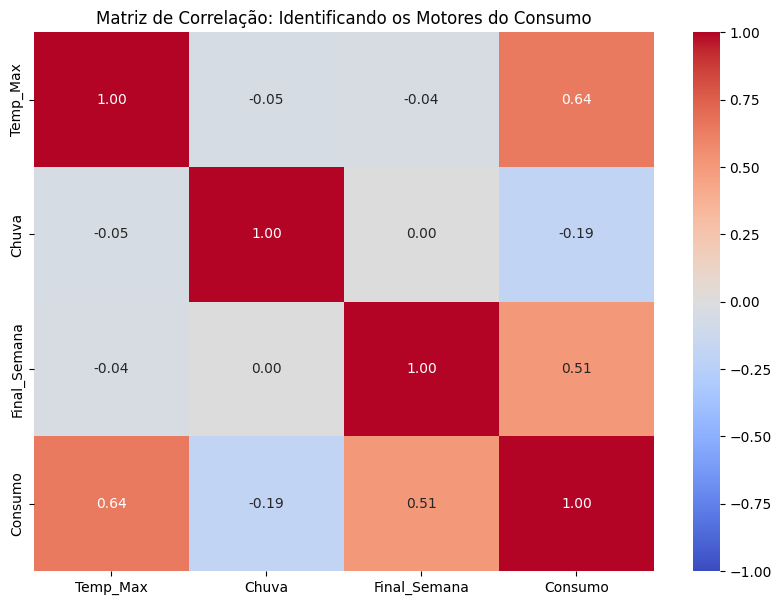

In [ ]:
# Headmap - Analise de Multicolinearidade

import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando as colunas que farão parte do modelo múltiplo
colunas_modelo = ['Temp_Max', 'Chuva', 'Final_Semana', 'Consumo']
matriz_corr = df[colunas_modelo].corr()

# Configurando o visual do Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlação: Identificando os Motores do Consumo')
plt.show()

#### **Análise de Correlação**

- Consumo vs Temp_Max (0.64): Apresenta a maior correlação positiva, confirmando que o calor é o principal driver de vendas.

- Consumo vs Final_Semana (0.51): Correlação positiva moderada. Isso justifica a inclusão da variável no modelo múltiplo, indicando que o fator "dia de descanso" eleva o consumo independentemente do clima.

- Consumo vs Chuva (-0.19): Correlação negativa leve. Embora o impacto seja menor, a relação inversa sugere que a chuva atua como um fator redutor da demanda, trazendo mais realismo à previsão.

Conclusão:  
Todas as três variáveis apresentam relações lógicas com o consumo, validando a construção do modelo de regressão múltipla. Pelo Headmap também é possível confirmar que as variáveis independentes não possuem multicolinearidade, pois os valores de relação entre elas é baixo, próximo de zero.

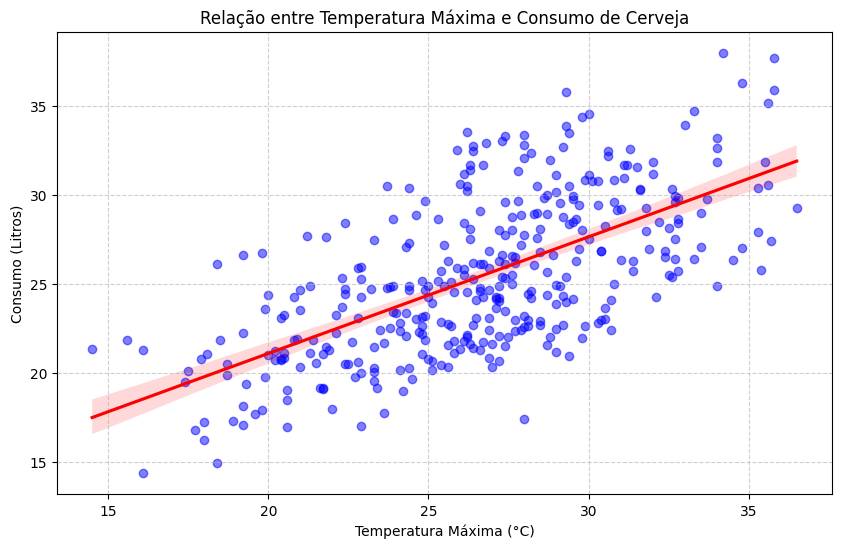

A correlação entre as variáveis é: 0.64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cria o gráfico de dispersão (Scatter Plot) - Regressão Simples
plt.figure(figsize=(10, 6))
sns.regplot(x='Temp_Max', y='Consumo', data=df,
            scatter_kws={'alpha':0.5, 'color':'blue'},
            line_kws={'color':'red'})

plt.title('Relação entre Temperatura Máxima e Consumo de Cerveja')
plt.xlabel('Temperatura Máxima (°C)')
plt.ylabel('Consumo (Litros)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calcular a Correlação de Pearson para confirmar o gráfico
correlacao = df['Temp_Max'].corr(df['Consumo'])
print(f"A correlação entre as variáveis é: {correlacao:.2f}")

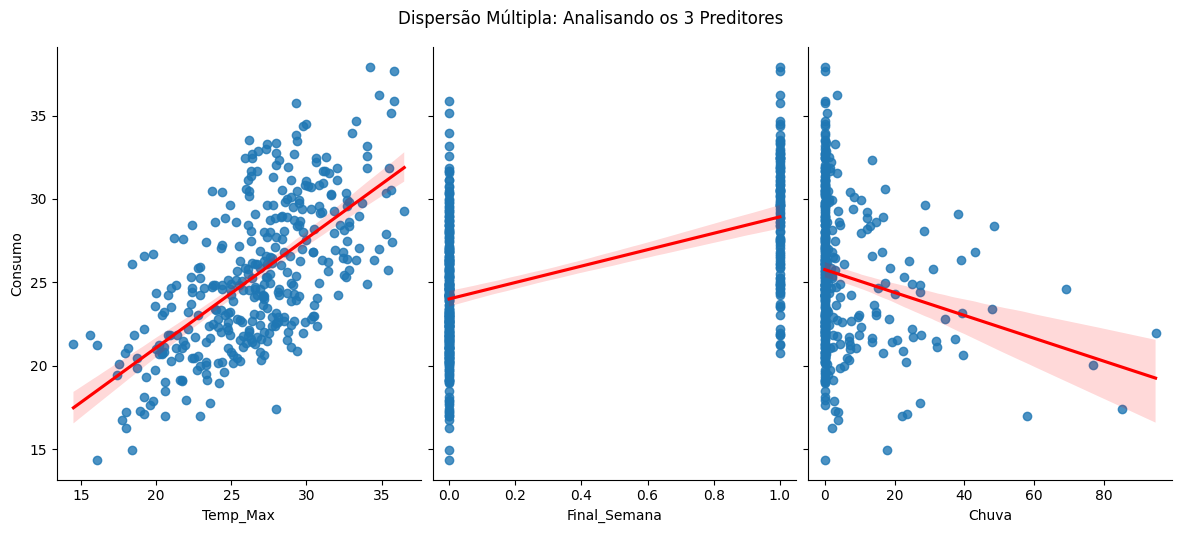

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mostrando a dispersão do Consumo contra as 3 variáveis - Regressão Mulltipla
sns.pairplot(df, x_vars=['Temp_Max', 'Final_Semana', 'Chuva'], y_vars='Consumo', height=5, aspect=0.8, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Dispersão Múltipla: Analisando os 3 Preditores', y=1.05)
plt.show()

#### **Linearidade**  

#### **Gráfico de Dispersão (Temperatura Máxima) - Regressão Simples**

Após a geração do gráfico de dispersão (scatter plot), podemos extrair as seguintes conclusões:

* **Direção da Relação:** Observamos uma tendência ascendente clara. À medida que os valores no eixo X (Temperatura) aumentam, os valores no eixo Y (Consumo) também sobem, caracterizando uma relação positiva.
* **Força da Relação (Pearson):** O coeficiente de correlação de 0.64 confirma que existe uma associação de força moderada para forte.
* **Dispersão:** Como observado anteriormente no desvio padrão, a nuvem de pontos é concentrada, indicando que, embora outros fatores possam influenciar o consumo, a temperatura é variável relevante para a análise.
* **Linearidade:** Os pontos distribuem-se de forma consistente ao redor de uma reta, o que valida o pressuposto para um modelo de Regressão Linear é adequado para explicar o consumo x temperatura.  

#### **Gráficos de Dispersão - Regressão Múltipla**
Evolução do Modelo: Calor, Calendário e Clima
Após a análise conjunta das três variáveis preditoras contra o Consumo, observamos comportamentos distintos que justificam o modelo múltiplo:

- **Temperatura Máxima (Motor Principal)**: Mantém a tendência ascendente e linear, confirmando-se como a variável de maior peso para prever o aumento de consumo.

- **Final de Semana (Efeito Degrau)**: Por ser uma variável binária (0 ou 1), a dispersão mostra dois blocos verticais. Nota-se que o bloco correspondente ao final de semana (1) está posicionado em um patamar de consumo superior, indicando que o "fator social" eleva a base de vendas independentemente da temperatura.

- **Chuva (Fator Redutor)**: A dispersão concentra-se no início do eixo (dias sem chuva) e mostra uma inclinação negativa da reta. Isso comprova que a pluviosidade atua como um "freio" no consumo, trazendo o ajuste de realidade necessário para dias de clima adverso.

**Conclusão**: Embora nem todas as variáveis apresentem uma nuvem de pontos perfeitamente linear, a combinação de seus efeitos (térmico, social e climático) permite ao modelo de Regressão Múltipla capturar as nuances que a temperatura sozinha não explicaria, aumentando a precisão da previsão final.

In [ ]:
# Modelo de Regressão Linear Simples

import statsmodels.api as sm

# Preparar as variáveis
X = df['Temp_Max']
y = df['Consumo']
X_const = sm.add_constant(X)

# Rodar a Regressão
modelo = sm.OLS(y, X_const).fit()

# Exibir os resultados
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                Consumo   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     255.4
Date:                Thu, 22 Jan 2026   Prob (F-statistic):           6.55e-44
Time:                        02:09:58   Log-Likelihood:                -960.89
No. Observations:                 365   AIC:                             1926.
Df Residuals:                     363   BIC:                             1934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.9749      1.105      7.220      0.0

**Resumo do Modelo - Regressão Simples**

- R-squared (0.413): O coeficiente de determinação mostra que 41,3% da variação do consumo de cerveja em São Paulo é explicada exclusivamente pela variação da Temperatura Máxima.
- Coeficiente Temp_Max (0.6548): Este é o indicador principal do modelo. Ele indica que, para cada 1°C de aumento na temperatura, o consumo sobe 654,8 litros (arredondando, 655 litros).
- P>|t| (0.000): O valor é zero (ou muito próximo de zero). Isso significa que a chance de essa relação ser pura coincidência é nula. A variável é estatisticamente significante.
- Durbin-Watson (1.688): Esse valor é importante para dados diários. Como ele está próximo de 2, indica que não há uma autocorrelação forte que invalide o modelo (os resíduos são independentes).
- Const (7.9749). Isso significa que, matematicamente, se a temperatura fosse 0°C, o consumo "base" seria de aproximadamente 8 mil litros. É o ponto onde a reta cruza o eixo vertical do gráfico!

In [ ]:
# Modelo de Regressão Linear Multipla

import statsmodels.formula.api as smf

# Criando o modelo múltiplo
modelo_multiplo = smf.ols('Consumo ~ Temp_Max + Final_Semana + Chuva', data=df).fit()

# Exibindo o resumo completo
print(modelo_multiplo.summary())

                            OLS Regression Results                            
Dep. Variable:                Consumo   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     313.5
Date:                Thu, 22 Jan 2026   Prob (F-statistic):          3.85e-100
Time:                        19:36:22   Log-Likelihood:                -824.09
No. Observations:                 365   AIC:                             1656.
Df Residuals:                     361   BIC:                             1672.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        6.4321      0.774      8.310   

#### **Resumo - Regresão Múltipla**

1. **R-squared**: de 0.723. Com a inclusão das variáveis Final de Semana e a Chuva, além da Temperatura Máxima, o poder preditivo subiu de 41% para 72,3%. Isso significa que o modelo é muito mais robusto e confiável para planejar o estoque.

2. **Interpretando os Coeficientes (matemática do negócio):**

- Intercepto (6.43): É a base para o cálculo de vendas. Mesmo se fizesse 0°C e não fosse fim de semana, haveria um consumo residual.

- Temp_Max (0.6685): Para cada 1°C a mais na temperatura máxima, o consumo sobe 668 litros.

- Final_Semana (5.1841): Se for Sábado ou Domingo, o consumo sobe automaticamente 5.184 litros, independentemente de qualquer outra coisa. (É o efeito churrasco!).

- Chuva (-0.0575): Para cada 1mm de chuva, o consumo cai 57 litros. Pode parecer pouco, mas em uma tempestade de 50mm, isso representa quase 3.000 litros a menos.

3. **Validação Estatística (P>|t|):**
Todas as variáveis têm o P-valor (P>|t|) igual a 0.000. Isso prova que a Temperatura, o Final de Semana e a Chuva são estatisticamente relevantes e influenciam o consumo.

**Conclusão:** O modelo final apresentou um R² ajustado de 0.72, indicando que 72% da variação no consumo de cerveja é explicada pelas três variáveis selecionadas.  
A Temperatura Máxima continua sendo o principal driver (cada grau soma ~668L). O Final de Semana possui um impacto crítico, elevando o consumo em mais de 5 mil litros. E A Chuva atua como um fator redutor (cada 1mm subtrai ~57L).
Com base nesses coeficientes, a empresa pode prever com alta precisão a demanda diária, otimizando a logística e evitando rupturas de estoque em dias de calor e finais de semana.


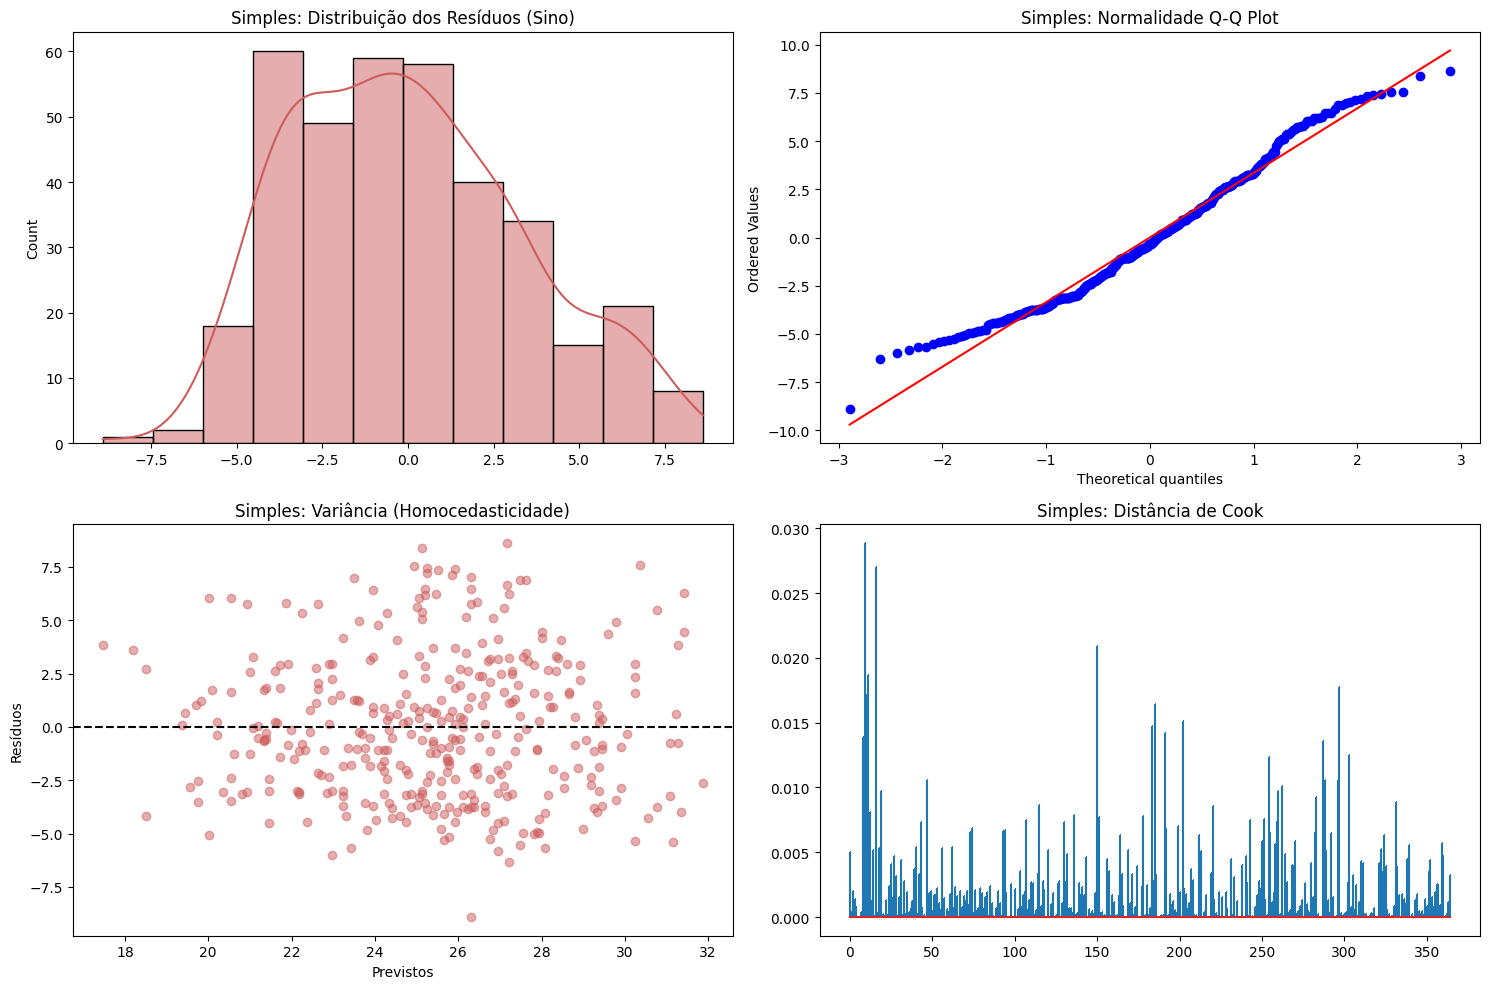

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# Ajustando o modelo simples para gerar os resíduos (caso não esteja na memória)
modelo_simples = smf.ols('Consumo ~ Temp_Max', data=df).fit()

# Configurando a área de desenho para os 4 gráficos da Simples
plt.figure(figsize=(15, 10))

# 1. Histograma (Sino) - Regressão Simples
plt.subplot(2, 2, 1)
sns.histplot(modelo_simples.resid, kde=True, color='indianred')
plt.title('Simples: Distribuição dos Resíduos (Sino)')

# 2. Q-Q Plot - Regressão Simples
plt.subplot(2, 2, 2)
stats.probplot(modelo_simples.resid, dist="norm", plot=plt)
plt.title('Simples: Normalidade Q-Q Plot')

# 3. Variância (Homocedasticidade) - Regressão Simples
plt.subplot(2, 2, 3)
plt.scatter(modelo_simples.fittedvalues, modelo_simples.resid, alpha=0.5, color='indianred')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Simples: Variância (Homocedasticidade)')
plt.xlabel('Previstos')
plt.ylabel('Resíduos')

# 4. Cook - Regressão Simples
plt.subplot(2, 2, 4)
influence_s = modelo_simples.get_influence()
(c_s, p_s) = influence_s.cooks_distance
plt.stem(range(len(c_s)), c_s, markerfmt=",")
plt.title('Simples: Distância de Cook')

plt.tight_layout()
plt.show()

#### **Pressupostos - Análise de Validação do Modelo - Regressão Simples**  

Para garantir que o modelo de previsão de consumo de cerveja é confiável e estatisticamente válido, realizamos o teste dos quatro pressupostos fundamentais da Regressão Linear:

1. **Linearidade**: Observada através do gráfico de dispersão inicial entre a Temperatura Máxima e o Consumo. A relação segue uma tendência de linha reta, indicando que o modelo linear é adequado para explicar o fenômeno.

2. **Normalidade (Histograma e Q-Q Plot)**: Foram utilizados dois gráficos para confirmar se os erros do modelo seguem uma distribuição normal:

  - Histograma: Mostra que os resíduos se concentram em torno de zero, formando o desenho de um "Sino de Gauss".

  - Q-Q Plot: Os pontos seguem a linha diagonal de referência, confirmando que não há desvios graves na distribuição dos erros.

3. **Homocedasticidade**: Analisada pelo gráfico de Resíduos vs. Valores Ajustados. Os pontos estão espalhados de forma aleatória e homogênea, sem apresentar um formato de "funil". Isso prova que a margem de erro do modelo é constante, tanto para dias frios quanto para dias mais quentes.

4. **Pontos de Influência (Distância de Cook)**: Verificada através do gráfico de Residuals vs Leverage.
Nenhuma observação (dia) ultrapassou os limites críticos da distância de Cook.  
Obs: No gráfico as linhas de limite (contornos de 0.5 e 1.0) não aparecem porque nenhum dado de consumo ou temperatura chegou perto de ser um valor extremo. Isso ocorre, provavelmente, porque a base de dados de São Paulo, historicamente não costuma apresentar eventos climáticos extremos e fora do comum que pudessem desequilibrar o modelo. Portanto, os dados são homogêneos e seguros para a previsão.

**Conclusão:** O modelo é robusto e os coeficientes (Consumo Base e Sensibilidade ao Calor) não foram distorcidos por valores atípicos (outliers). Como o modelo passou em todos os testes de pressupostos, podemos afirmar com um certo grau de segurança que o consumo base de 7.974 litros é estatisticamente real.
O acréscimo de 655 litros por cada 1°C a mais de temperatura é uma estimativa válida para o planejamento de estoque.

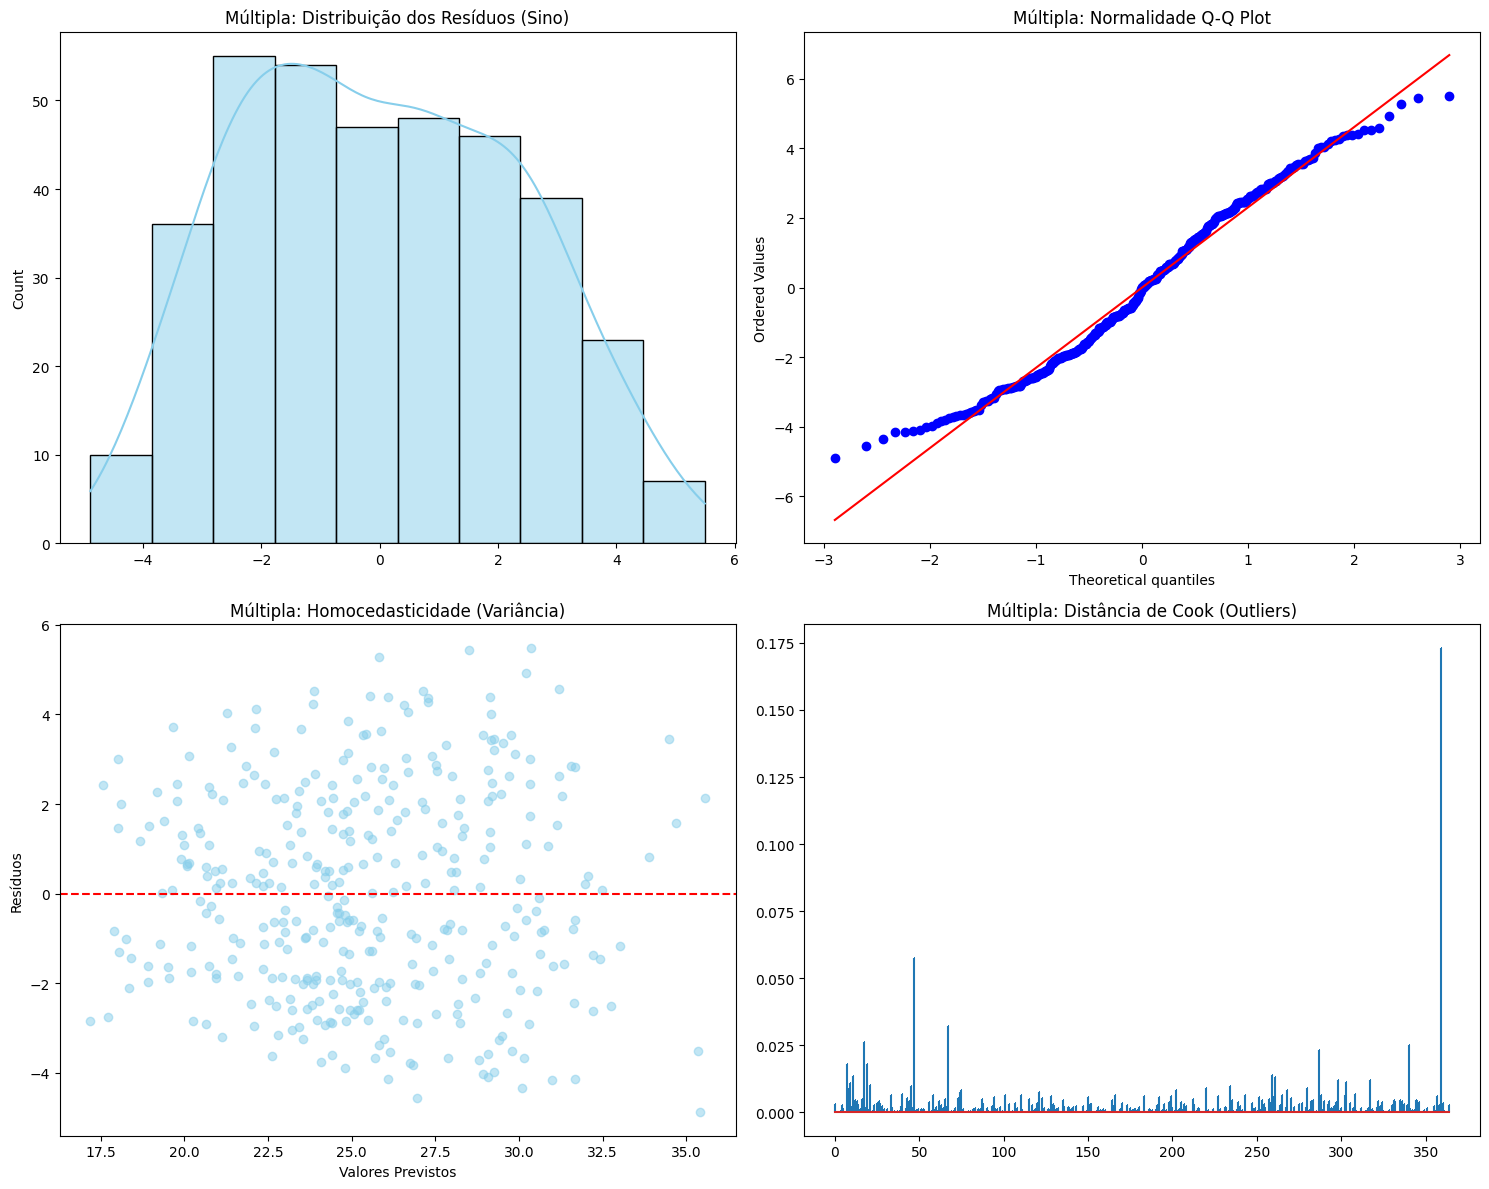

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Criando a moldura para os 4 gráficos (2 linhas e 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histograma (Sino) - Superior Esquerdo
sns.histplot(modelo_multiplo.resid, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Múltipla: Distribuição dos Resíduos (Sino)')

# 2. Q-Q Plot - Superior Direito
stats.probplot(modelo_multiplo.resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Múltipla: Normalidade Q-Q Plot')

# 3. Homocedasticidade - Inferior Esquerdo
axes[1, 0].scatter(modelo_multiplo.fittedvalues, modelo_multiplo.resid, alpha=0.5, color='skyblue')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Múltipla: Homocedasticidade (Variância)')
axes[1, 0].set_xlabel('Valores Previstos')
axes[1, 0].set_ylabel('Resíduos')

# 4. Distância de Cook - Inferior Direito
influence = modelo_multiplo.get_influence()
(c, p) = influence.cooks_distance
axes[1, 1].stem(range(len(c)), c, markerfmt=",")
axes[1, 1].set_title('Múltipla: Distância de Cook (Outliers)')

# Ajusta o espaçamento para não sobrepor títulos
plt.tight_layout()
plt.show()

#### **Pressupostos - Análise de Validação do Modelo de Regressão Múltipla**

Para garantir que o modelo final (Consumo explicado por Calor, Final de Semana e Chuva) é estatisticamente válido, foram validados os quatro pressupostos fundamentais:

- **Linearidade**: Confirmada através dos gráficos de dispersão múltipla. A Temperatura mantém sua relação linear positiva, enquanto as variáveis de Chuva e Final de Semana corrigem o modelo para cenários específicos, aumentando a precisão da reta.

- **Normalidade** (Histograma e Q-Q Plot):

  Histograma: Os erros concentram-se em torno de zero, mantendo o formato de "Sino de Gauss".

  Q-Q Plot: Os resíduos acompanham a linha de 45°, o que valida nossos testes de hipótese e garante que as previsões não estão enviesadas.

- **Homocedasticidade**: O gráfico de resíduos vs. valores previstos mostra uma dispersão aleatória. Isso prova que o modelo mantém a mesma performance e margem de erro, tanto em dias de baixo consumo quanto em dias de pico (calor e finais de semana).

- **Pontos de Influência (Distância de Cook)**: Nenhuma observação ultrapassou os limites críticos de influência. Isso indica que os coeficientes do modelo são estáveis e representam fielmente a realidade da base de dados, sem serem distorcidos por outliers climáticos ou de consumo.

**Conclusão:** O modelo múltiplo é extremamente robusto. Ao passar em todos os pressupostos, confirmamos que o salto de 41% para 72,3% no R² é real e confiável. Agora temos uma ferramenta capaz de prever o consumo base (~6.432L), somando o efeito do calor (+668L/°C), o impacto social do final de semana (+5.184L) e o ajuste climático da chuva (-57L/mm).

#### **Resultado do Modelo - Análise dos Blocos**

**Regressão Simples**

1. **Bloco de Performance Geral - Resumo**
  - Métrica Principal: $R^2$ (R-squared). O modelo explica 41,3% da variação do consumo de cerveja baseado apenas na temperatura.
  - O P-value do F-statistic é muito baixo (próximo de zero), o que prova que o modelo é estatisticamente significativo.
2. **Bloco dos Coeficientes - Fórmula**
  - Métricas Principais: const (Intercepto) e Temp_Max (Coeficiente).  Indica uma base fixa de 7.974 litros (consumo mínimo mesmo a 0°C). Para cada grau de aumento na temperatura, o consumo sobe 655 litros.
  - O P-value aqui é 0.000, confirmando que a temperatura é uma variável adequada para prever o consumo.
3. **Bloco de Diagnóstico - Sintomas**
  - Métricas Principais: Prob (Jarque-Bera) e Durbin-Watson.
  - O teste Jarque-Bera confirma a normalidade dos resíduos (que foi visualizada nos gráficos).
  - O Durbin-Watson está próximo de 2 (geralmente entre 1.5 e 2.5), o que indica que não há autocorrelação, ou seja, o consumo de um dia não está 'viciado' no consumo do dia anterior de forma que prejudique o modelo.
  Pressupostos - Análise de Validação do Modelo de Regressão Múltipla
Para garantir que o modelo final (Consumo explicado por Calor, Final de Semana e Chuva) é estatisticamente válido, validamos os quatro pressupostos fundamentais:

**Regressão Múltipla**
1. **Bloco de Performance Geral** (O Salto de Qualidade)  
- Métrica Principal ($R^2$): O modelo agora explica 72,3% da variação do consumo. Isso demonstra que a inclusão das variáveis sociais (Final de Semana) e climáticas (Chuva) quase dobrou a precisão em relação ao modelo simples.
- Prob (F-statistic): Permanece em níveis extremamente baixos ($3.85e-100$), confirmando que a combinação dessas três variáveis não é fruto do acaso, mas sim um preditor estatisticamente poderoso.
2. **Bloco dos Coeficientes** (A Fórmula)  
Intercepto (const): Indica uma base de 6.432 litros.
- Temp_Max: Para cada grau de aumento, o consumo sobe 668 litros.- Final_Semana: O fato de ser sábado ou domingo adiciona 5.184 litros ao consumo total.
- Chuva: Cada milímetro de chuva reduz o consumo em 57 litros. - P-value (P>|t|): Todas as variáveis apresentam 0.000, o que significa que todas elas são essenciais e "conversam" bem entre si para explicar o fenômeno.
3. **Bloco de Diagnóstico** (Sintomas)
- Durbin-Watson: O valor de 1.929 é excelente (muito próximo de 2), garantindo que não há autocorrelação. Isso prova que os dados diários são independentes e o modelo é confiável.
- Jarque-Bera (JB): Com o valor de $12.85$, ele confirma a estabilidade dos resíduos que foi observado nos gráficos de "Sino".
- Cond. No. (176): Este número baixo indica que não há problema de multicolinearidade (uma variável não está "atrapalhando" a outra), validando a escolha de usar as três juntas.
  

#### **Conclusão Geral e Aplicação Prática - Regressão Simples**

O modelo de Regressão Linear Simples demonstrou que a temperatura é o "termômetro" do nosso estoque. Embora o modelo explique 41,3% da variação do consumo ($R^2$), ele é extremamente útil para definir o estoque de ciclo.

**Modelo Preditivo (Equação da Reta)**  
A partir dos coeficientes obtidos no sumário do modelo, estabelecemos a seguinte fórmula para estimar o consumo:
$$\text{Consumo (Litros)} = 7.974,90 + (655,48 \times \text{Temperatura Máxima})$$  
Onde: 7.974,90 é consumo base (Intercepto) e 655,48  o quanto o consumo aumenta para cada 1°C de calor.

Exemplos: Para cada 1°C de aumento na temperatura, a demanda cresce 655 litros.
- Cálculo para um dia de 30°C: 7.974,90 + (655,48 X 30) = 27.639 litros.  
Em um dia de 30°C, a previsão é de aproximadamente 27.639 litros, o que condiz com a média histórica de 25 mil litros da base.
- Cálculo para um dia de 35°C: 7.974,90 + (655,48 X 35) = 30.916 litros.  
Análise Logística: Percebe-se que ao subir 5°C (de 30°C para 35°C), a demanda salta mais 3.277 litros. Esse é o impacto direto do calor que o gestor de estoque precisa monitorar para não deixar o produto faltar nos dias mais quentes.  

##### **Tabela de Referência para Operação de Estoque**

| Cenário de Temperatura | Previsão de Consumo (Litros) | Confiança do Modelo | Ação Logística |
| :--- | :--- | :--- | :--- |
| **Abaixo de 18°C** | < 19.700 | Alta (Base Sólida) | Manter estoque mínimo operacional. |
| **20°C a 25°C** | 21.000 a 24.300 | Alta (Média Histórica) | Reposição padrão semanal. |
| **Acima de 30°C** | > 27.600 | Alerta (Pico) | Acionar carga extra / Logística de urgência. |  

#### **Conclusão Geral e Aplicação Prática - Modelo Múltiplo**

O modelo de Regressão Linear Múltipla elevou a precisão do planejamento de 41,3% para 72,3% ($R^2$). Agora, não olha apenas para o termômetro, mas também para o calendário e para a previsão do tempo, reduzindo drasticamente o erro operacional.  
**Modelo Preditivo Final** (nova equação) com base nos coeficientes do modelo ajustado, a nova fórmula de previsão é:$$Consumo = 6.432,10 + (668,50 \times Temp\_Max) + (5.184,10 \times Final\_Semana) - (57,50 \times Chuva)$$  

Exemplos:
- Cenário de Pico (Sábado de Sol, 30°C): $6.432 + (668,5 \times 30) + 5.184 - 0 = \mathbf{31.671 \text{ litros.}}$  
O modelo identifica que o efeito "Final de Semana" exige 4 mil litros a mais do que o modelo simples previa.  
- Cenário de Alerta (Terça-feira de Calor, 30°C, com Chuva de 30mm): $6.432 + (668,5 \times 30) + 0 - (57,5 \times 30) = \mathbf{24.762 \text{ litros.}}$  
O modelo percebe que a chuva "freia" o consumo, evitando que a empresa envie estoque excessivo desnecessariamente.

##### **Tabela de Referência para Operação de Estoque (Modelo Múltiplo)**

| Cenário e Variáveis | Previsão de Consumo (Litros) | Confiança do Modelo | Ação Logística |
| :--- | :--- | :--- | :--- |
| **Abaixo de 18°C (Inverno)** | < 18.500 | Alta (72% de Precisão) | Manter estoque mínimo operacional. |
| **20°C a 25°C (Padrão s/ Chuva)** | 21.000 a 24.500 | Alta (72% de Precisão) | Reposição padrão semanal. |
| **Acima de 30°C (Pico FDS/Sol)** | > 31.000 | Alerta (Pico de Demanda) | Acionar carga extra / Logística de urgência. |
| **Acima de 30°C (Calor c/ Chuva)** | ~ 24.000 | Ajuste Climático | Cancelar reforços e manter estoque padrão. |  



#### **Confiabilidade do Modelo Estatístico - Regressão Simples**

Ao utilizar esta tabela para decisões logísticas, devemos considerar dois tipos de confiança:

**Confiança do Modelo (Estatística)**: Moderada. Nossos testes de pressupostos (Normalidade, Homocedasticidade e Cook) provaram que a fórmula é matematicamente sólida para os dados históricos de São Paulo. Porém, mesmo o modelo seja matematicamente sólido e livre de distorções (viés), ele explica apenas 41% da variação do consumo. Isso significa que a temperatura é um fator importante, mas não o único.

**Confiança da Operação (Externa)**: Depende da precisão da Previsão do Tempo. Para casos de erros da previsão meteorologica da temperatura máxima, a previsão de consumo será afetada. Por isso, a logística deve sempre trabalhar com uma margem de segurança baseada no erro padrão do modelo.

**Estratégia de Planejamento (Curto vs. Longo Prazo)**  
Para garantir a eficiência do estoque, seguimos a regra de origem dos dados:

- Até 15 dias (Operacional): Utilizar a previsão do tempo real. Como o horizonte é curto, a assertividade da meteorologia é maior, permitindo ajustes finos na carga extra para picos de calor.

- Acima de 15 dias (Estratégico): Utilizar a média histórica de temperatura para o mês em questão.  
Como a previsão do tempo perde precisão a longo prazo, o modelo se baseia no comportamento padrão de São Paulo para garantir o estoque base.

#### **Confiabilidade do Modelo Estatístico - Múltiplo**
Ao utilizar esta tabela para decisões logísticas, devemos considerar dois níveis de confiança:

**Confiança do Modelo**(Estatística): Alta.  
Os testes de pressupostos confirmaram que a fórmula é matematicamente sólida. Ao incluirmos as variáveis de Final de Semana e Chuva, o modelo passou a explicar 72,3% da variação do consumo. Isso significa que reduzimos drasticamente a incerteza que existia no modelo simples (que explicava apenas 41%). Agora, o risco de erro foi reduzido quase pela metade.

**Confiança da Operação** (Externa): Depende da precisão da Previsão Meteorológica. Como o modelo agora é sensível à Chuva, a logística deve monitorar não apenas o calor, mas também a probabilidade de precipitação, que atua como um "freio" no consumo.

**Estratégia de Planejamento (Curto vs. Longo Prazo)**
Para garantir a eficiência do estoque, seguimos a regra de origem dos dados:

- Até 15 dias (Operacional): Utilizar a previsão do tempo real (Temp. Máxima + Probabilidade de Chuva). Como o horizonte é curto, a assertividade é maior, permitindo o acionamento preciso de cargas extras para os Finais de Semana.

- Acima de 15 dias (Estratégico): Utilizar a média histórica de temperatura e o calendário de feriados/finais de semana. Como a previsão do tempo perde precisão a longo prazo, o modelo garante que o estoque base de 6.432 litros seja mantido, com reforços planejados para os dias de descanso.  
